# 🏏 IPL Match Winner Prediction with Hyperparameter Optimization

**Project goal:** Predict whether **Team 1 wins the IPL match** using only **pre-match and toss-time information**, then compare **Random Search** and **Bayesian Optimization (Optuna)** for tuning a deep learning model.

This notebook is intentionally aligned to a machine learning optimization project rubric:

- Clear preprocessing pipeline
- Deep learning model built in **TensorFlow / Keras**
- Baseline hyperparameter tuning with **Random Search**
- Advanced tuning with **Bayesian Optimization (Optuna)**
- Comparison using **accuracy, F1, ROC-AUC, runtime, number of trials, and convergence**
- Discussion of **optimizer choice, dropout, weight decay, and learning-rate scheduling**
- Evaluation with confusion matrix and error analysis
- Global + local explainability using **SHAP**
- Fixed random seeds for reproducibility

> **Prediction framing used here:** the model predicts the winner **after the toss but before the match starts**.  
> This avoids target leakage from post-match fields such as result margin, target runs, player of the match, or winner-dependent statistics.

## 0. Environment and dependency notes

This notebook uses:

- `tensorflow`
- `optuna`
- `shap`
- `scikit-learn`
- `pandas`, `numpy`, `matplotlib`, `seaborn`

If any package is missing in your environment, install it before running:

```bash
pip install tensorflow optuna shap seaborn
```

> `lime` is not required here because both the **global** and **local** explanation sections are implemented with **SHAP**.

In [1]:
!pip install tensorflow optuna shap seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 113.7 kB/s eta 0:00:00


In [2]:
# Reproducibility + core imports
import os
import random
import time
import zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    log_loss,
)
from sklearn.dummy import DummyClassifier

import shap
import optuna
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks, models

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

print("TensorFlow version:", tf.__version__)
print("Optuna version:", optuna.__version__)
print("SHAP version:", shap.__version__)

TensorFlow version: 2.19.0
Optuna version: 4.8.0
SHAP version: 0.51.0


## 1. Load the dataset robustly

The notebook tries multiple locations in this order:

1. `matches.csv` in the current folder
2. `ipl_dataset/matches.csv`
3. extract from `ipl_dataset.zip` if needed

This makes the notebook easier to run both locally and from the uploaded files.

In [3]:
def locate_matches_csv():
    candidate_files = [
        Path("matches.csv"),
        Path("ipl_dataset/matches.csv"),
        Path("/mnt/data/ipl_dataset/matches.csv"),
    ]
    for path in candidate_files:
        if path.exists():
            return path

    candidate_zips = [
        Path("ipl_dataset.zip"),
        Path("/mnt/data/ipl_dataset.zip"),
    ]
    for zip_path in candidate_zips:
        if zip_path.exists():
            extract_dir = Path("ipl_dataset")
            extract_dir.mkdir(exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(".")
            extracted = Path("ipl_dataset/matches.csv")
            if extracted.exists():
                return extracted

    raise FileNotFoundError(
        "Could not find matches.csv. Place matches.csv beside the notebook, "
        "or keep it inside ipl_dataset/matches.csv, or provide ipl_dataset.zip."
    )

matches_path = locate_matches_csv()
df_raw = pd.read_csv(matches_path)

print("Loaded file:", matches_path)
print("Shape:", df_raw.shape)
display(df_raw.head())

Loaded file: matches.csv
Shape: (1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## 2. Problem framing and leakage control

The original IPL match file contains columns that are **not valid as pre-match predictors** because they are known only after the match finishes.

Examples of columns **excluded** from modeling:

- `winner` (target itself)
- `player_of_match`
- `result`, `result_margin`
- `target_runs`, `target_overs`
- `method`

We keep only features that are available before or at toss time, and we also engineer **historical features** from *earlier matches only* to avoid leakage.

In [4]:
# Quick audit of columns
audit_df = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "missing_values": [int(df_raw[c].isna().sum()) for c in df_raw.columns],
})
display(audit_df)

,column,dtype,missing_values
0,id,int64,0
1,season,object,0
2,city,object,51
3,date,object,0
4,match_type,object,0
5,player_of_match,object,5
6,venue,object,0
7,team1,object,0
8,team2,object,0
9,toss_winner,object,0


## 3. Clean the data and standardize team names

Some franchises were renamed across seasons.  
To reduce unnecessary sparsity, obvious naming variations are standardized:

- `Delhi Daredevils` → `Delhi Capitals`
- `Kings XI Punjab` → `Punjab Kings`
- `Royal Challengers Bangalore` → `Royal Challengers Bengaluru`
- `Rising Pune Supergiant` → `Rising Pune Supergiants`

This improves modeling consistency without changing the underlying match outcomes.

In [5]:
TEAM_NAME_MAP = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
}

df = df_raw.copy()

for col in ["team1", "team2", "toss_winner", "winner"]:
    df[col] = df[col].replace(TEAM_NAME_MAP)

# Drop rows where winner is unknown (abandoned/no result)
df = df.dropna(subset=["winner"]).copy()

# Keep only matches where the recorded winner is one of the two teams in that match
df = df[df.apply(lambda r: r["winner"] in {r["team1"], r["team2"]}, axis=1)].copy()

# Parse date and create simple calendar features
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values(["date", "id"]).reset_index(drop=True)

def extract_season_start(season_value):
    season_value = str(season_value)
    return int(season_value[:4]) if season_value[:4].isdigit() else np.nan

df["season_start_year"] = df["season"].apply(extract_season_start)
df["match_month"] = df["date"].dt.month.astype(int)

# Binary target: did team1 win?
df["team1_win"] = (df["winner"] == df["team1"]).astype(int)

print("Cleaned shape:", df.shape)
print("Unique teams after standardization:", sorted(set(df["team1"]).union(df["team2"])))
display(df.head())

Cleaned shape: (1090, 23)
Unique teams after standardization: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,season_start_year,match_month,team1_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2007,4,0
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,2007,4,0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,2007,4,1
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,2007,4,0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,2007,4,1


## 4. Feature engineering using only prior information

To make the task more realistic and informative, we build **leakage-safe historical features** by processing matches in chronological order.

For each match, we compute only what was known **before that match happened**:

- `team1_prior_win_rate`
- `team2_prior_win_rate`
- `team1_vs_team2_prior_win_rate`
- `toss_winner_prior_win_rate`
- `team1_is_toss_winner`

A small amount of **Laplace smoothing** is used so that brand-new teams do not produce undefined ratios.

In [6]:
def add_historical_features(matches_df):
    team_wins = defaultdict(int)
    team_games = defaultdict(int)
    head2head_wins = defaultdict(int)

    team1_prior_win_rate = []
    team2_prior_win_rate = []
    team1_vs_team2_prior_win_rate = []
    toss_winner_prior_win_rate = []
    team1_is_toss_winner = []

    for _, row in matches_df.iterrows():
        t1 = row["team1"]
        t2 = row["team2"]
        toss_w = row["toss_winner"]
        winner = row["winner"]

        # Team-level prior win rates with Laplace smoothing
        t1_rate = (team_wins[t1] + 1) / (team_games[t1] + 2)
        t2_rate = (team_wins[t2] + 1) / (team_games[t2] + 2)

        # Directed head-to-head history: P(team1 beats team2) before this match
        t1_over_t2 = head2head_wins[(t1, t2)]
        t2_over_t1 = head2head_wins[(t2, t1)]
        h2h_rate = (t1_over_t2 + 1) / (t1_over_t2 + t2_over_t1 + 2)

        toss_rate = (team_wins[toss_w] + 1) / (team_games[toss_w] + 2)

        team1_prior_win_rate.append(t1_rate)
        team2_prior_win_rate.append(t2_rate)
        team1_vs_team2_prior_win_rate.append(h2h_rate)
        toss_winner_prior_win_rate.append(toss_rate)
        team1_is_toss_winner.append(int(toss_w == t1))

        # Update historical state AFTER recording the features
        team_games[t1] += 1
        team_games[t2] += 1
        team_wins[winner] += 1

        loser = t2 if winner == t1 else t1
        head2head_wins[(winner, loser)] += 1

    out = matches_df.copy()
    out["team1_prior_win_rate"] = team1_prior_win_rate
    out["team2_prior_win_rate"] = team2_prior_win_rate
    out["team1_vs_team2_prior_win_rate"] = team1_vs_team2_prior_win_rate
    out["toss_winner_prior_win_rate"] = toss_winner_prior_win_rate
    out["team1_is_toss_winner"] = team1_is_toss_winner
    return out

df = add_historical_features(df)

historical_cols = [
    "team1_prior_win_rate",
    "team2_prior_win_rate",
    "team1_vs_team2_prior_win_rate",
    "toss_winner_prior_win_rate",
    "team1_is_toss_winner",
]
display(df[["date", "team1", "team2", "winner"] + historical_cols].head(10))

,date,team1,team2,winner,team1_prior_win_rate,team2_prior_win_rate,team1_vs_team2_prior_win_rate,toss_winner_prior_win_rate,team1_is_toss_winner
0,2008-04-18,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,0.500000,0.500000,0.5,0.500000,1
1,2008-04-19,Punjab Kings,Chennai Super Kings,Chennai Super Kings,0.500000,0.500000,0.5,0.500000,0
2,2008-04-19,Delhi Capitals,Rajasthan Royals,Delhi Capitals,0.500000,0.500000,0.5,0.500000,0
3,2008-04-20,Mumbai Indians,Royal Challengers Bengaluru,Royal Challengers Bengaluru,0.500000,0.333333,0.5,0.500000,1
4,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,0.666667,0.500000,0.5,0.500000,0
5,2008-04-21,Rajasthan Royals,Punjab Kings,Rajasthan Royals,0.333333,0.333333,0.5,0.333333,0
6,2008-04-22,Deccan Chargers,Delhi Capitals,Delhi Capitals,0.333333,0.666667,0.5,0.333333,1
7,2008-04-23,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,0.666667,0.333333,0.5,0.333333,0
8,2008-04-24,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0.250000,0.500000,0.5,0.500000,0
9,2008-04-25,Punjab Kings,Mumbai Indians,Punjab Kings,0.250000,0.250000,0.5,0.250000,0


## 5. Exploratory checks

These checks are useful for the report:

- class balance
- season coverage
- feature preview
- whether the prediction target is heavily imbalanced

If the target were very imbalanced, we would discuss class weighting.  
For IPL match outcomes, the binary target is usually reasonably balanced, so standard binary classification metrics are suitable.

Date range: 2008-04-18 to 2024-05-26
Rows available for modeling: 1090



,percentage
team1_win,
Team1 wins,50.92
Team2 wins,49.08


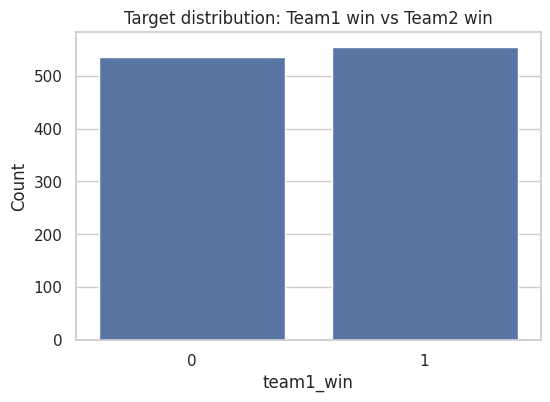

,count,mean,std,min,25%,50%,75%,max
season_start_year,1090.0,2016.015596,5.113113,2007.000000,2012.000000,2016.000000,2021.000000,2024.000000
match_month,1090.0,4.828440,1.614591,3.000000,4.000000,4.000000,5.000000,11.000000
team1_prior_win_rate,1090.0,0.512091,0.083015,0.187500,0.470674,0.510289,0.569199,0.833333
team2_prior_win_rate,1090.0,0.517809,0.085938,0.166667,0.476190,0.514218,0.567975,0.800000
team1_vs_team2_prior_win_rate,1090.0,0.494792,0.129632,0.142857,0.407828,0.500000,0.571429,0.857143
toss_winner_prior_win_rate,1090.0,0.515741,0.086022,0.200000,0.476839,0.513336,0.568182,0.833333
team1_is_toss_winner,1090.0,0.388073,0.487535,0.000000,0.000000,0.000000,1.000000,1.000000


In [7]:
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Rows available for modeling:", len(df))
print()

class_balance = df["team1_win"].value_counts(normalize=True).rename(index={0: "Team2 wins", 1: "Team1 wins"})
display((class_balance * 100).round(2).to_frame("percentage"))

plt.figure(figsize=(6, 4))
sns.countplot(x=df["team1_win"])
plt.title("Target distribution: Team1 win vs Team2 win")
plt.xlabel("team1_win")
plt.ylabel("Count")
plt.show()

display(df[["season_start_year", "match_month"] + historical_cols].describe().T)

## 6. Select features and create a chronological split

A chronological split is used instead of a random split so the evaluation is closer to real forecasting:

- **Train:** oldest 70%
- **Validation:** next 15%
- **Test:** newest 15%

This avoids using future matches to tune the model for earlier matches.

In [8]:
feature_cols = [
    "season_start_year",
    "match_month",
    "match_type",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "team1_prior_win_rate",
    "team2_prior_win_rate",
    "team1_vs_team2_prior_win_rate",
    "toss_winner_prior_win_rate",
    "team1_is_toss_winner",
]
target_col = "team1_win"

model_df = df[["date", "winner"] + feature_cols + [target_col]].copy()

n_total = len(model_df)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

X_train_df = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(int).to_numpy()

X_val_df = val_df[feature_cols].copy()
y_val = val_df[target_col].astype(int).to_numpy()

X_test_df = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(int).to_numpy()

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")
print()
print("Train class balance:", round(y_train.mean(), 3))
print("Val class balance:  ", round(y_val.mean(), 3))
print("Test class balance: ", round(y_test.mean(), 3))

Train size: 763
Validation size: 163
Test size: 164

Train class balance: 0.522
Val class balance:   0.442
Test class balance:  0.518


## 7. Preprocessing pipeline

### Why this matters for optimization

Preprocessing directly affects optimization stability and final performance:

- **One-hot encoding** prevents the model from interpreting team or venue IDs as if they were ordered numeric values.
- **Standardization** of numeric features puts them on comparable scales, which improves gradient-based optimization.
- No augmentation is used because this is a **tabular classification** problem, not an image or text generation task.

In [9]:
categorical_cols = [
    "match_type",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
]

numeric_cols = [
    "season_start_year",
    "match_month",
    "team1_prior_win_rate",
    "team2_prior_win_rate",
    "team1_vs_team2_prior_win_rate",
    "toss_winner_prior_win_rate",
    "team1_is_toss_winner",
]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols),
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train.shape)
print("Processed val shape:", X_val.shape)
print("Processed test shape:", X_test.shape)

display(pd.DataFrame({"feature_name": feature_names}).head(20))

Processed train shape: (763, 128)
Processed val shape: (163, 128)
Processed test shape: (164, 128)


,feature_name
0,num__season_start_year
1,num__match_month
2,num__team1_prior_win_rate
3,num__team2_prior_win_rate
4,num__team1_vs_team2_prior_win_rate
5,num__toss_winner_prior_win_rate
6,num__team1_is_toss_winner
7,cat__match_type_3rd Place Play-Off
8,cat__match_type_Elimination Final
9,cat__match_type_Eliminator


## 8. Helper functions for modeling, evaluation, and tuning

In [10]:
def build_optimizer(optimizer_name, learning_rate):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if optimizer_name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    if optimizer_name == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def build_mlp(input_dim, hidden_units=64, dropout_rate=0.2, optimizer_name="adam",
              learning_rate=1e-3, weight_decay=1e-4):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(
            hidden_units,
            activation="relu",
            kernel_regularizer=regularizers.l2(weight_decay),
        ),
        layers.Dropout(dropout_rate),
        layers.Dense(
            max(hidden_units // 2, 16),
            activation="relu",
            kernel_regularizer=regularizers.l2(weight_decay),
        ),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid"),
    ])

    optimizer = build_optimizer(optimizer_name, learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def evaluate_probabilities(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-7, 1 - 1e-7)),
    }
    return out


def make_callbacks(use_lr_schedule=False):
    cb = [
        callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=0,
        )
    ]
    if use_lr_schedule:
        cb.append(
            callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=4,
                min_lr=1e-5,
                verbose=0,
            )
        )
    return cb


def train_and_score(params, X_tr, y_tr, X_va, y_va, weight_decay=1e-4,
                    use_lr_schedule=False, epochs=60, verbose=0):
    tf.keras.backend.clear_session()

    model = build_mlp(
        input_dim=X_tr.shape[1],
        hidden_units=params["hidden_units"],
        dropout_rate=params["dropout_rate"],
        optimizer_name=params["optimizer"],
        learning_rate=params["learning_rate"],
        weight_decay=weight_decay,
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=params["batch_size"],
        callbacks=make_callbacks(use_lr_schedule=use_lr_schedule),
        verbose=verbose,
    )

    val_prob = model.predict(X_va, verbose=0).ravel()
    metrics = evaluate_probabilities(y_va, val_prob)
    metrics["best_epoch"] = int(np.argmax(history.history["val_auc"]) + 1)
    return model, history, metrics

## 9. Simple baselines

We compare the optimized models against two baselines:

1. **Dummy classifier** — predicts the most frequent class
2. **Simple MLP baseline** — reasonable neural network defaults without tuning

This makes it easier to show the value of optimization.

In [11]:
# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_val_prob = np.full_like(y_val, fill_value=dummy.predict_proba(X_val)[:, 1][0], dtype=float)
dummy_metrics_val = evaluate_probabilities(y_val, dummy_val_prob)

dummy_metrics_val

{'accuracy': 0.44171779141104295,
 'f1': 0.6127659574468085,
 'precision': 0.44171779141104295,
 'recall': 1.0,
 'roc_auc': np.float64(0.5),
 'log_loss': 8.998446082730712}

In [12]:
baseline_params = {
    "hidden_units": 64,
    "dropout_rate": 0.2,
    "optimizer": "adam",
    "learning_rate": 1e-3,
    "batch_size": 32,
}

baseline_model, baseline_history, baseline_val_metrics = train_and_score(
    baseline_params,
    X_train, y_train,
    X_val, y_val,
    weight_decay=1e-4,
    use_lr_schedule=False,
    epochs=60,
    verbose=0,
)

print("Simple MLP baseline validation metrics:")
display(pd.DataFrame([baseline_val_metrics]).round(4))

Simple MLP baseline validation metrics:


,accuracy,f1,precision,recall,roc_auc,log_loss,best_epoch
0,0.4417,0.4678,0.404,0.5556,0.4686,0.8218,6


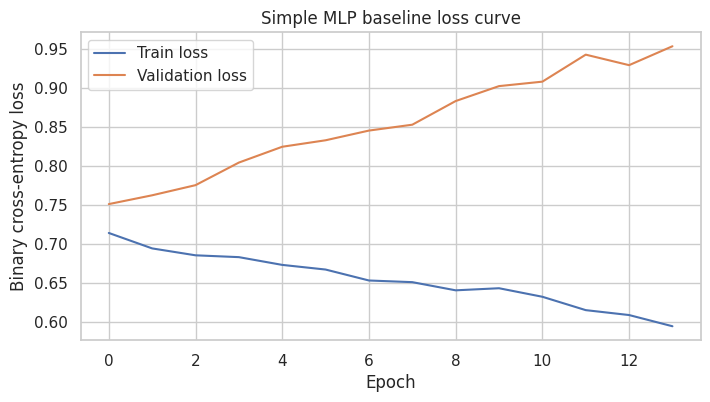

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(baseline_history.history["loss"], label="Train loss")
plt.plot(baseline_history.history["val_loss"], label="Validation loss")
plt.title("Simple MLP baseline loss curve")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
plt.show()

## 10. Hyperparameter search space

The search space is kept the **same** for both Random Search and Bayesian Optimization to ensure a fair comparison.

**Tuned hyperparameters:**
- learning rate
- batch size
- dropout rate
- hidden units
- optimizer type (`adam`, `sgd`, `rmsprop`)

In [14]:
SEARCH_SPACE = {
    "learning_rate_low": 1e-4,
    "learning_rate_high": 3e-2,
    "batch_size_choices": [16, 32, 64, 128],
    "dropout_rate_choices": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "hidden_units_choices": [32, 64, 128, 256],
    "optimizer_choices": ["adam", "sgd", "rmsprop"],
}

def sample_random_params(rng):
    return {
        "learning_rate": float(np.exp(rng.uniform(
            np.log(SEARCH_SPACE["learning_rate_low"]),
            np.log(SEARCH_SPACE["learning_rate_high"])
        ))),
        "batch_size": int(rng.choice(SEARCH_SPACE["batch_size_choices"])),
        "dropout_rate": float(rng.choice(SEARCH_SPACE["dropout_rate_choices"])),
        "hidden_units": int(rng.choice(SEARCH_SPACE["hidden_units_choices"])),
        "optimizer": str(rng.choice(SEARCH_SPACE["optimizer_choices"])),
    }

## 11. Baseline tuning method: Random Search

In [15]:
RANDOM_SEARCH_TRIALS = 50
rng = np.random.default_rng(SEED)

random_search_results = []
random_best_model = None
random_best_history = None
random_best_params = None
random_best_auc = -np.inf

start_random = time.perf_counter()

for trial_idx in range(1, RANDOM_SEARCH_TRIALS + 1):
    params = sample_random_params(rng)

    model, history, metrics = train_and_score(
        params,
        X_train, y_train,
        X_val, y_val,
        weight_decay=1e-4,
        use_lr_schedule=False,
        epochs=60,
        verbose=0,
    )

    row = {"trial": trial_idx, **params, **metrics}
    random_search_results.append(row)

    if metrics["roc_auc"] > random_best_auc:
        random_best_auc = metrics["roc_auc"]
        random_best_model = model
        random_best_history = history
        random_best_params = params

random_search_time = time.perf_counter() - start_random
random_df = pd.DataFrame(random_search_results).sort_values("roc_auc", ascending=False).reset_index(drop=True)

print(f"Random Search finished in {random_search_time:.2f} seconds")
display(random_df.head(10).round(4))
print("Best Random Search params:", random_best_params)

Random Search finished in 173.20 seconds


,trial,learning_rate,batch_size,dropout_rate,hidden_units,optimizer,accuracy,f1,precision,recall,roc_auc,log_loss,best_epoch
0,35,0.0005,128,0.5,64,rmsprop,0.5828,0.4138,0.5455,0.3333,0.5792,0.6804,4
1,6,0.0004,16,0.3,256,adam,0.4847,0.5922,0.4552,0.8472,0.5591,0.6961,1
2,25,0.0130,16,0.1,256,adam,0.5583,0.0000,0.0000,0.0000,0.5420,0.6850,1
3,34,0.0241,32,0.5,64,rmsprop,0.6012,0.4538,0.5745,0.3750,0.5410,0.6924,8
4,13,0.0002,64,0.2,64,adam,0.5521,0.1412,0.4615,0.0833,0.5360,0.6918,1
5,19,0.0056,32,0.4,128,sgd,0.5337,0.5914,0.4825,0.7639,0.5324,0.7037,1
6,15,0.0054,16,0.1,256,rmsprop,0.5153,0.0706,0.2308,0.0417,0.5275,3.4997,14
7,37,0.0002,32,0.5,32,sgd,0.5399,0.4000,0.4717,0.3472,0.5172,0.6898,1
8,3,0.0077,64,0.4,128,adam,0.4724,0.4110,0.4054,0.4167,0.5169,0.6967,1
9,18,0.0001,128,0.4,256,sgd,0.5583,0.0000,0.0000,0.0000,0.5143,0.6917,1


Best Random Search params: {'learning_rate': 0.00045560883012629716, 'batch_size': 128, 'dropout_rate': 0.5, 'hidden_units': 64, 'optimizer': 'rmsprop'}


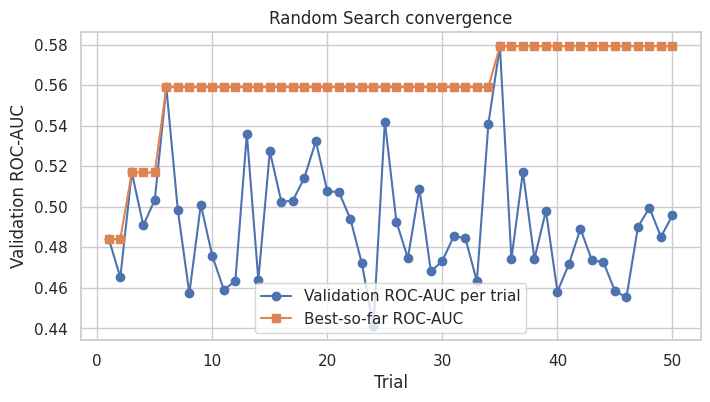

In [16]:
random_df_plot = random_df.sort_values("trial").copy()
random_df_plot["best_so_far_auc"] = random_df_plot["roc_auc"].cummax()

plt.figure(figsize=(8, 4))
plt.plot(random_df_plot["trial"], random_df_plot["roc_auc"], marker="o", label="Validation ROC-AUC per trial")
plt.plot(random_df_plot["trial"], random_df_plot["best_so_far_auc"], marker="s", label="Best-so-far ROC-AUC")
plt.title("Random Search convergence")
plt.xlabel("Trial")
plt.ylabel("Validation ROC-AUC")
plt.legend()
plt.show()

## 12. Advanced tuning method: Bayesian Optimization with Optuna

Optuna uses a **TPE sampler** to search the same space more efficiently than pure random sampling.

In [17]:
OPTUNA_TRIALS = 50
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_objective(trial):
    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            SEARCH_SPACE["learning_rate_low"],
            SEARCH_SPACE["learning_rate_high"],
            log=True,
        ),
        "batch_size": trial.suggest_categorical("batch_size", SEARCH_SPACE["batch_size_choices"]),
        "dropout_rate": trial.suggest_categorical("dropout_rate", SEARCH_SPACE["dropout_rate_choices"]),
        "hidden_units": trial.suggest_categorical("hidden_units", SEARCH_SPACE["hidden_units_choices"]),
        "optimizer": trial.suggest_categorical("optimizer", SEARCH_SPACE["optimizer_choices"]),
    }

    _, history, metrics = train_and_score(
        params,
        X_train, y_train,
        X_val, y_val,
        weight_decay=1e-4,
        use_lr_schedule=False,
        epochs=60,
        verbose=0,
    )

    trial.set_user_attr("accuracy", metrics["accuracy"])
    trial.set_user_attr("f1", metrics["f1"])
    trial.set_user_attr("precision", metrics["precision"])
    trial.set_user_attr("recall", metrics["recall"])
    trial.set_user_attr("roc_auc", metrics["roc_auc"])
    trial.set_user_attr("log_loss", metrics["log_loss"])
    trial.set_user_attr("best_epoch", metrics["best_epoch"])
    return metrics["roc_auc"]

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)

start_optuna = time.perf_counter()
study.optimize(optuna_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
optuna_time = time.perf_counter() - start_optuna

optuna_best_params = study.best_trial.params
print(f"Optuna finished in {optuna_time:.2f} seconds")
print("Best Optuna params:", optuna_best_params)
print("Best validation ROC-AUC:", round(study.best_value, 4))

Optuna finished in 188.05 seconds
Best Optuna params: {'learning_rate': 0.00019746733539895237, 'batch_size': 128, 'dropout_rate': 0.2, 'hidden_units': 256, 'optimizer': 'sgd'}
Best validation ROC-AUC: 0.5694


In [18]:
# Train a fresh model with the best Optuna parameters so that we also keep the history object
optuna_best_model, optuna_best_history, optuna_best_val_metrics = train_and_score(
    optuna_best_params,
    X_train, y_train,
    X_val, y_val,
    weight_decay=1e-4,
    use_lr_schedule=False,
    epochs=60,
    verbose=0,
)

optuna_trials_df = study.trials_dataframe().rename(columns={"value": "roc_auc"}).copy()

for metric_name in ["accuracy", "f1", "precision", "recall", "log_loss", "best_epoch"]:
    optuna_trials_df[metric_name] = [t.user_attrs.get(metric_name, np.nan) for t in study.trials]

display(
    optuna_trials_df[
        ["number", "params_learning_rate", "params_batch_size", "params_dropout_rate",
         "params_hidden_units", "params_optimizer", "roc_auc", "accuracy", "f1", "best_epoch"]
    ].sort_values("roc_auc", ascending=False).head(10).round(4)
)

,number,params_learning_rate,params_batch_size,params_dropout_rate,params_hidden_units,params_optimizer,roc_auc,accuracy,f1,best_epoch
15,15,0.0002,128,0.2,256,sgd,0.5694,0.5460,0.4308,20
42,42,0.0007,64,0.4,32,sgd,0.5575,0.5521,0.0267,1
28,28,0.0006,64,0.4,32,sgd,0.5531,0.5460,0.4559,49
33,33,0.0005,64,0.4,32,sgd,0.5520,0.5521,0.1978,12
31,31,0.0006,64,0.4,32,sgd,0.5462,0.4601,0.6140,2
34,34,0.0004,64,0.4,32,sgd,0.5394,0.5644,0.2366,2
32,32,0.0007,64,0.4,32,sgd,0.5388,0.5399,0.0260,1
40,40,0.0004,16,0.4,128,sgd,0.5356,0.5215,0.5000,3
1,1,0.0012,32,0.2,64,sgd,0.5351,0.5460,0.0000,1
27,27,0.0006,64,0.4,32,sgd,0.5348,0.5153,0.3969,4


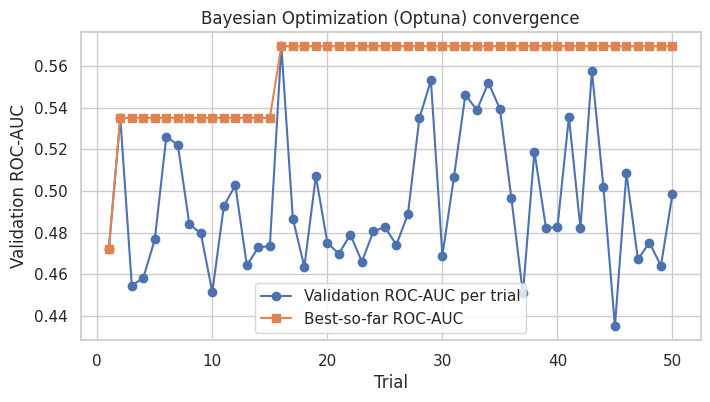

In [19]:
optuna_plot_df = optuna_trials_df.sort_values("number").copy()
optuna_plot_df["best_so_far_auc"] = optuna_plot_df["roc_auc"].cummax()

plt.figure(figsize=(8, 4))
plt.plot(optuna_plot_df["number"] + 1, optuna_plot_df["roc_auc"], marker="o", label="Validation ROC-AUC per trial")
plt.plot(optuna_plot_df["number"] + 1, optuna_plot_df["best_so_far_auc"], marker="s", label="Best-so-far ROC-AUC")
plt.title("Bayesian Optimization (Optuna) convergence")
plt.xlabel("Trial")
plt.ylabel("Validation ROC-AUC")
plt.legend()
plt.show()

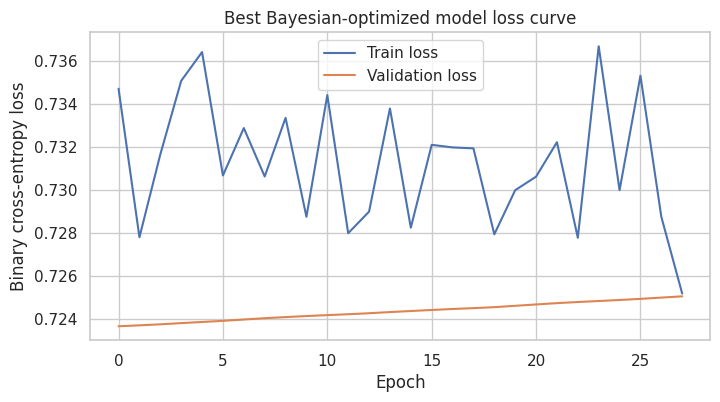

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(optuna_best_history.history["loss"], label="Train loss")
plt.plot(optuna_best_history.history["val_loss"], label="Validation loss")
plt.title("Best Bayesian-optimized model loss curve")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
plt.show()

## 13. Compare Random Search vs Bayesian Optimization

This section compares:

- best validation performance
- runtime
- number of trials
- convergence behavior
- best hyperparameters found

In [21]:
comparison_search_df = pd.DataFrame([
    {
        "method": "Random Search",
        "trials": RANDOM_SEARCH_TRIALS,
        "runtime_seconds": random_search_time,
        "best_val_accuracy": random_df["accuracy"].max(),
        "best_val_f1": random_df["f1"].max(),
        "best_val_roc_auc": random_df["roc_auc"].max(),
        "best_hidden_units": random_best_params["hidden_units"],
        "best_dropout_rate": random_best_params["dropout_rate"],
        "best_optimizer": random_best_params["optimizer"],
        "best_batch_size": random_best_params["batch_size"],
        "best_learning_rate": random_best_params["learning_rate"],
    },
    {
        "method": "Bayesian Optimization (Optuna)",
        "trials": OPTUNA_TRIALS,
        "runtime_seconds": optuna_time,
        "best_val_accuracy": optuna_trials_df["accuracy"].max(),
        "best_val_f1": optuna_trials_df["f1"].max(),
        "best_val_roc_auc": optuna_trials_df["roc_auc"].max(),
        "best_hidden_units": optuna_best_params["hidden_units"],
        "best_dropout_rate": optuna_best_params["dropout_rate"],
        "best_optimizer": optuna_best_params["optimizer"],
        "best_batch_size": optuna_best_params["batch_size"],
        "best_learning_rate": optuna_best_params["learning_rate"],
    },
])

display(comparison_search_df.round(4))

,method,trials,runtime_seconds,best_val_accuracy,best_val_f1,best_val_roc_auc,best_hidden_units,best_dropout_rate,best_optimizer,best_batch_size,best_learning_rate
0,Random Search,50,173.1980,0.6012,0.6234,0.5792,64,0.5,rmsprop,128,0.0005
1,Bayesian Optimization (Optuna),50,188.0469,0.5644,0.6234,0.5694,256,0.2,sgd,128,0.0002


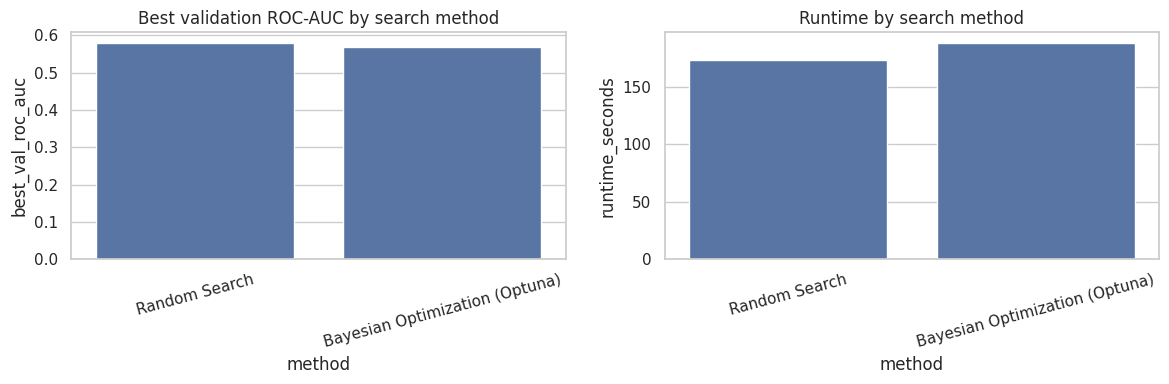

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=comparison_search_df, x="method", y="best_val_roc_auc", ax=axes[0])
axes[0].set_title("Best validation ROC-AUC by search method")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=comparison_search_df, x="method", y="runtime_seconds", ax=axes[1])
axes[1].set_title("Runtime by search method")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 14. Optimizer and regularization analysis

The rubric also asks for a discussion of:

- **optimizer choice** (`Adam`, `SGD`, `RMSProp`)
- **dropout**
- **weight decay (L2 regularization)**
- **learning-rate schedules**

To address this clearly, we run focused ablation experiments around the tuned architecture.

### Why these matter

- **Adam** usually converges faster and is robust on mixed sparse/tabular inputs.
- **SGD + momentum** can generalize well but is more sensitive to learning rate and typically slower to stabilize.
- **RMSProp** can be effective on noisy gradients but sometimes gives less consistent generalization than Adam on tabular data.
- **Dropout** helps reduce co-adaptation and overfitting.
- **Weight decay** penalizes large weights and improves generalization.
- **Learning-rate schedules** can help the optimizer fine-tune after the fast early phase.

In [23]:
anchor_params = optuna_best_params.copy()

optimizer_ablation_rows = []
for opt_name in SEARCH_SPACE["optimizer_choices"]:
    trial_params = anchor_params.copy()
    trial_params["optimizer"] = opt_name

    _, history, metrics = train_and_score(
        trial_params,
        X_train, y_train,
        X_val, y_val,
        weight_decay=1e-4,
        use_lr_schedule=False,
        epochs=60,
        verbose=0,
    )
    optimizer_ablation_rows.append({
        "optimizer": opt_name,
        **metrics,
    })

optimizer_ablation_df = pd.DataFrame(optimizer_ablation_rows).sort_values("roc_auc", ascending=False)
display(optimizer_ablation_df.round(4))

,optimizer,accuracy,f1,precision,recall,roc_auc,log_loss,best_epoch
2,rmsprop,0.5399,0.2857,0.4545,0.2083,0.5508,0.6867,1
0,adam,0.5644,0.3107,0.5161,0.2222,0.5385,0.6850,1
1,sgd,0.4847,0.5281,0.4434,0.6528,0.4959,0.6994,4


In [24]:
regularization_experiments = [
    {"setting": "No dropout, no weight decay, no LR schedule", "dropout_rate": 0.0, "weight_decay": 0.0, "use_lr_schedule": False},
    {"setting": "Dropout only", "dropout_rate": anchor_params["dropout_rate"], "weight_decay": 0.0, "use_lr_schedule": False},
    {"setting": "Weight decay only", "dropout_rate": 0.0, "weight_decay": 1e-4, "use_lr_schedule": False},
    {"setting": "Dropout + weight decay", "dropout_rate": anchor_params["dropout_rate"], "weight_decay": 1e-4, "use_lr_schedule": False},
    {"setting": "Dropout + weight decay + LR schedule", "dropout_rate": anchor_params["dropout_rate"], "weight_decay": 1e-4, "use_lr_schedule": True},
]

regularization_rows = []
for exp in regularization_experiments:
    trial_params = anchor_params.copy()
    trial_params["dropout_rate"] = exp["dropout_rate"]

    _, history, metrics = train_and_score(
        trial_params,
        X_train, y_train,
        X_val, y_val,
        weight_decay=exp["weight_decay"],
        use_lr_schedule=exp["use_lr_schedule"],
        epochs=60,
        verbose=0,
    )

    regularization_rows.append({
        "setting": exp["setting"],
        "dropout_rate": exp["dropout_rate"],
        "weight_decay": exp["weight_decay"],
        "lr_schedule": exp["use_lr_schedule"],
        **metrics,
    })

regularization_df = pd.DataFrame(regularization_rows).sort_values("roc_auc", ascending=False)
display(regularization_df.round(4))

,setting,dropout_rate,weight_decay,lr_schedule,accuracy,f1,precision,recall,roc_auc,log_loss,best_epoch
4,Dropout + weight decay + LR schedule,0.2,0.0001,True,0.4969,0.5638,0.4569,0.7361,0.5394,0.6949,2
1,Dropout only,0.2,0.0000,False,0.5337,0.3667,0.4583,0.3056,0.5168,0.6897,1
0,"No dropout, no weight decay, no LR schedule",0.0,0.0000,False,0.4724,0.6055,0.4521,0.9167,0.5145,0.7115,6
3,Dropout + weight decay,0.2,0.0001,False,0.5276,0.6351,0.4820,0.9306,0.5032,0.7024,1
2,Weight decay only,0.0,0.0001,False,0.4417,0.6128,0.4417,1.0000,0.4435,0.7443,15


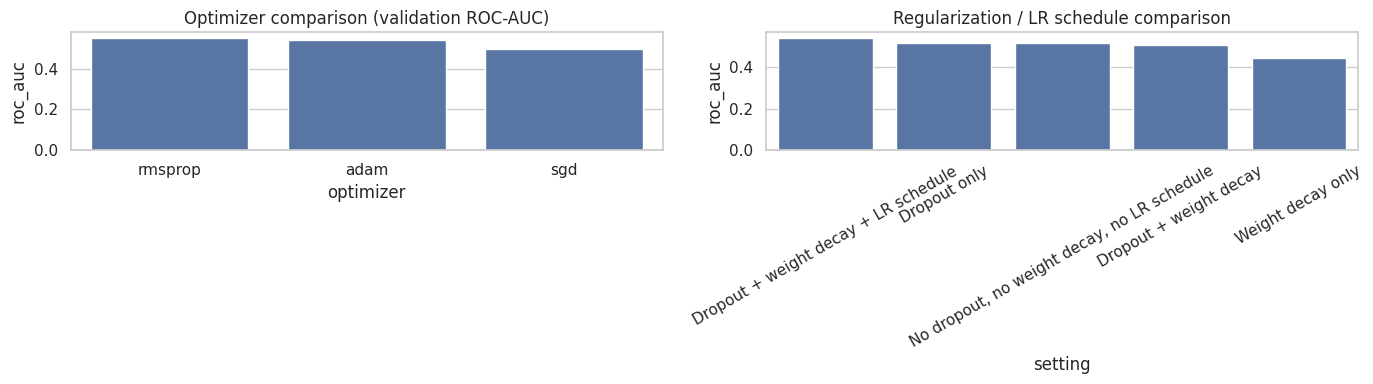

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=optimizer_ablation_df, x="optimizer", y="roc_auc", ax=axes[0])
axes[0].set_title("Optimizer comparison (validation ROC-AUC)")

sns.barplot(data=regularization_df, x="setting", y="roc_auc", ax=axes[1])
axes[1].set_title("Regularization / LR schedule comparison")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 15. Train final models for test-set evaluation

To evaluate fairly on the test set, each selected model is retrained on **train + validation**, while using an internal validation split only for early stopping.

Compared on test set:

- Dummy baseline
- Simple MLP baseline
- Best Random Search model
- Best Bayesian Optimization model

In [26]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

def fit_final_model(params, X_trval, y_trval, weight_decay=1e-4, use_lr_schedule=False, epochs=80, verbose=0):
    tf.keras.backend.clear_session()
    model = build_mlp(
        input_dim=X_trval.shape[1],
        hidden_units=params["hidden_units"],
        dropout_rate=params["dropout_rate"],
        optimizer_name=params["optimizer"],
        learning_rate=params["learning_rate"],
        weight_decay=weight_decay,
    )

    history = model.fit(
        X_trval, y_trval,
        validation_split=0.15,
        epochs=epochs,
        batch_size=params["batch_size"],
        callbacks=make_callbacks(use_lr_schedule=use_lr_schedule),
        verbose=verbose,
    )
    return model, history

# Dummy on train+val
dummy_final = DummyClassifier(strategy="most_frequent")
dummy_final.fit(X_trainval, y_trainval)
dummy_test_prob = np.full_like(y_test, fill_value=dummy_final.predict_proba(X_test)[:, 1][0], dtype=float)

# Simple baseline MLP on train+val
baseline_final_model, baseline_final_history = fit_final_model(
    baseline_params,
    X_trainval, y_trainval,
    weight_decay=1e-4,
    use_lr_schedule=False,
    epochs=80,
    verbose=0,
)
baseline_test_prob = baseline_final_model.predict(X_test, verbose=0).ravel()

# Best Random Search model on train+val
random_final_model, random_final_history = fit_final_model(
    random_best_params,
    X_trainval, y_trainval,
    weight_decay=1e-4,
    use_lr_schedule=False,
    epochs=80,
    verbose=0,
)
random_test_prob = random_final_model.predict(X_test, verbose=0).ravel()

# Best Bayesian/Optuna model on train+val
optuna_final_model, optuna_final_history = fit_final_model(
    optuna_best_params,
    X_trainval, y_trainval,
    weight_decay=1e-4,
    use_lr_schedule=True,  # use the schedule in final training if it helped the ablation
    epochs=80,
    verbose=0,
)
optuna_test_prob = optuna_final_model.predict(X_test, verbose=0).ravel()

In [27]:
test_results = pd.DataFrame([
    {"model": "Dummy baseline", **evaluate_probabilities(y_test, dummy_test_prob)},
    {"model": "Simple MLP baseline", **evaluate_probabilities(y_test, baseline_test_prob)},
    {"model": "Best Random Search MLP", **evaluate_probabilities(y_test, random_test_prob)},
    {"model": "Best Bayesian / Optuna MLP", **evaluate_probabilities(y_test, optuna_test_prob)},
]).sort_values("roc_auc", ascending=False).reset_index(drop=True)

display(test_results.round(4))

,model,accuracy,f1,precision,recall,roc_auc,log_loss
0,Simple MLP baseline,0.5244,0.3607,0.5946,0.2588,0.5663,0.6887
1,Best Bayesian / Optuna MLP,0.5183,0.5775,0.5294,0.6353,0.5275,0.6922
2,Best Random Search MLP,0.5427,0.5399,0.5641,0.5176,0.5126,0.6949
3,Dummy baseline,0.5183,0.6827,0.5183,1.0000,0.5000,7.7642


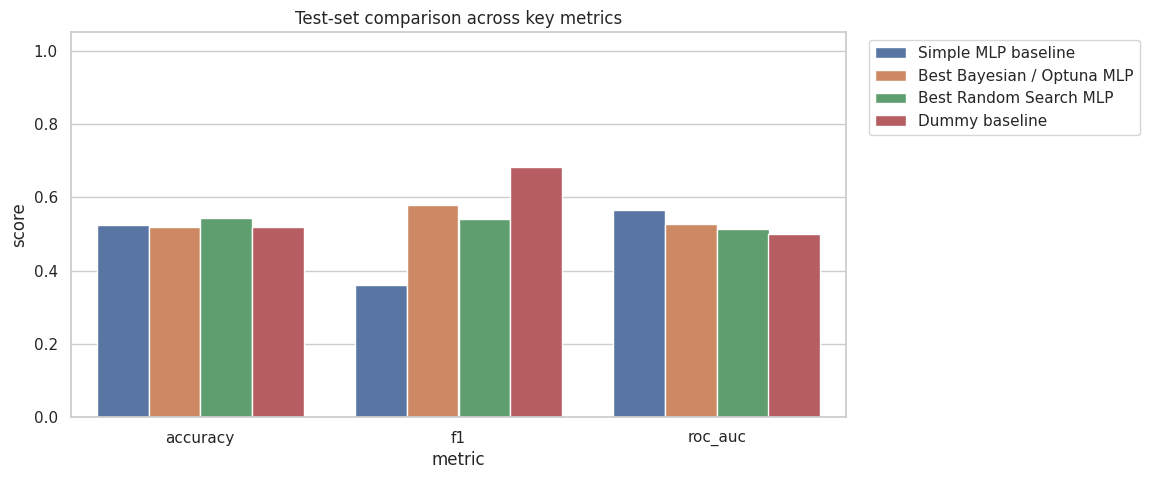

In [28]:
metric_plot_df = test_results.melt(id_vars="model", value_vars=["accuracy", "f1", "roc_auc"], var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=metric_plot_df, x="metric", y="score", hue="model")
plt.title("Test-set comparison across key metrics")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 16. Confusion matrix, ROC curves, and classification report

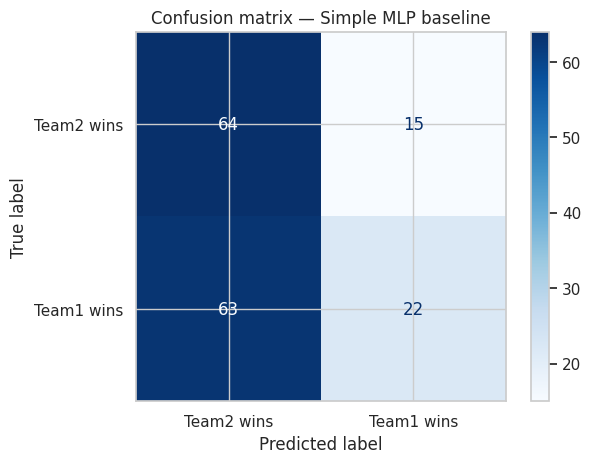

Classification report — Simple MLP baseline
              precision    recall  f1-score   support

  Team2 wins       0.50      0.81      0.62        79
  Team1 wins       0.59      0.26      0.36        85

    accuracy                           0.52       164
   macro avg       0.55      0.53      0.49       164
weighted avg       0.55      0.52      0.49       164



In [29]:
best_model_name = test_results.iloc[0]["model"]

prob_lookup = {
    "Dummy baseline": dummy_test_prob,
    "Simple MLP baseline": baseline_test_prob,
    "Best Random Search MLP": random_test_prob,
    "Best Bayesian / Optuna MLP": optuna_test_prob,
}
best_test_prob = prob_lookup[best_model_name]
best_test_pred = (best_test_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, best_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Team2 wins", "Team1 wins"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion matrix — {best_model_name}")
plt.show()

print(f"Classification report — {best_model_name}")
print(classification_report(y_test, best_test_pred, target_names=["Team2 wins", "Team1 wins"]))

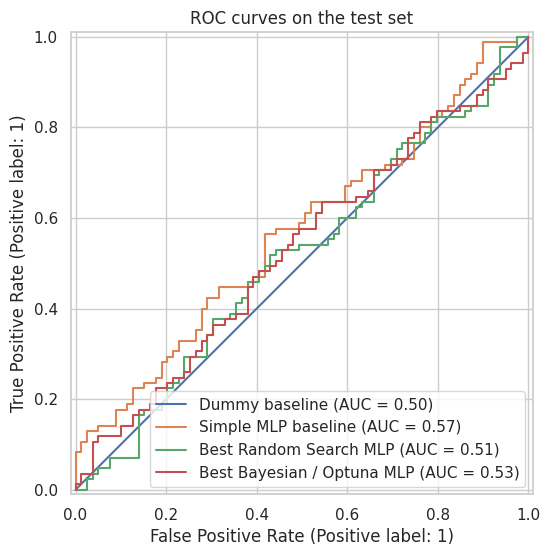

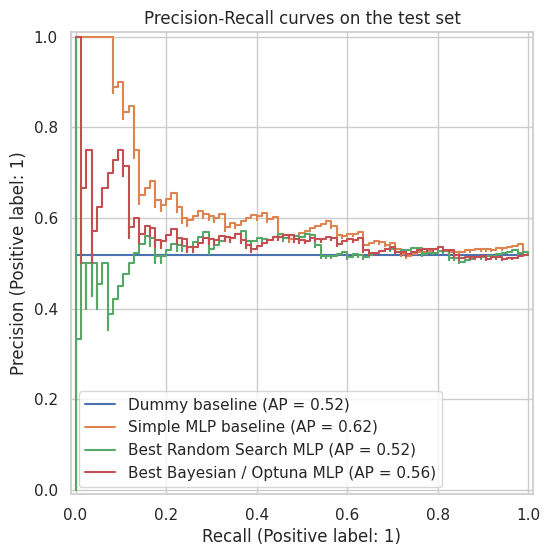

In [30]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for model_name, probs in prob_lookup.items():
    RocCurveDisplay.from_predictions(y_test, probs, name=model_name, ax=ax)
ax.set_title("ROC curves on the test set")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for model_name, probs in prob_lookup.items():
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=model_name, ax=ax)
ax.set_title("Precision-Recall curves on the test set")
plt.show()

## 17. Error analysis

A confusion matrix is useful but not sufficient.  
This section inspects **which matches the model gets wrong**, especially the **high-confidence mistakes**.

That is valuable for the report because it helps explain limitations such as:

- venue shifts
- franchise transitions
- unusual playoff matches
- noisy toss effects
- hidden factors not captured in the dataset (injuries, lineups, pitch conditions, form on the day)

In [31]:
analysis_df = test_df.copy().reset_index(drop=True)
analysis_df["pred_prob_team1_win"] = best_test_prob
analysis_df["pred_label"] = (analysis_df["pred_prob_team1_win"] >= 0.5).astype(int)
analysis_df["actual_label"] = y_test

analysis_df["predicted_winner"] = np.where(
    analysis_df["pred_label"] == 1,
    analysis_df["team1"],
    analysis_df["team2"],
)
analysis_df["actual_winner"] = np.where(
    analysis_df["actual_label"] == 1,
    analysis_df["team1"],
    analysis_df["team2"],
)
analysis_df["confidence"] = np.where(
    analysis_df["pred_label"] == 1,
    analysis_df["pred_prob_team1_win"],
    1 - analysis_df["pred_prob_team1_win"],
)
analysis_df["correct"] = (analysis_df["pred_label"] == analysis_df["actual_label"]).astype(int)

errors_df = analysis_df[analysis_df["correct"] == 0].sort_values("confidence", ascending=False)
display(errors_df[
    ["date", "team1", "team2", "toss_winner", "toss_decision", "venue",
     "predicted_winner", "actual_winner", "pred_prob_team1_win", "confidence"]
].head(10))

,date,team1,team2,toss_winner,toss_decision,venue,predicted_winner,actual_winner,pred_prob_team1_win,confidence
59,2023-04-29,Sunrisers Hyderabad,Delhi Capitals,Sunrisers Hyderabad,bat,"Arun Jaitley Stadium, Delhi",Delhi Capitals,Sunrisers Hyderabad,0.392308,0.607692
105,2024-03-31,Delhi Capitals,Chennai Super Kings,Delhi Capitals,bat,"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",Chennai Super Kings,Delhi Capitals,0.422649,0.577351
127,2024-04-20,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,"Arun Jaitley Stadium, Delhi",Delhi Capitals,Sunrisers Hyderabad,0.424380,0.575620
56,2023-04-27,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,bat,"Sawai Mansingh Stadium, Jaipur",Chennai Super Kings,Rajasthan Royals,0.426076,0.573924
95,2024-03-23,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,"Eden Gardens, Kolkata",Sunrisers Hyderabad,Kolkata Knight Riders,0.426208,0.573792
36,2023-04-12,Rajasthan Royals,Chennai Super Kings,Chennai Super Kings,field,"MA Chidambaram Stadium, Chepauk, Chennai",Chennai Super Kings,Rajasthan Royals,0.431346,0.568654
99,2024-03-26,Chennai Super Kings,Gujarat Titans,Gujarat Titans,field,"MA Chidambaram Stadium, Chepauk, Chennai",Gujarat Titans,Chennai Super Kings,0.434468,0.565532
138,2024-04-28,Chennai Super Kings,Sunrisers Hyderabad,Sunrisers Hyderabad,field,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Chennai Super Kings,0.435747,0.564253
100,2024-03-27,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,"Rajiv Gandhi International Stadium, Uppal, Hyderabad",Mumbai Indians,Sunrisers Hyderabad,0.436539,0.563461
142,2024-05-02,Sunrisers Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,bat,"Rajiv Gandhi International Stadium, Uppal, Hyderabad",Rajasthan Royals,Sunrisers Hyderabad,0.438250,0.561750


,test_matches,accuracy,error_rate
venue,,,
"Arun Jaitley Stadium, Delhi",12,0.3333,0.6667
"Barsapara Cricket Stadium, Guwahati",3,0.3333,0.6667
"Brabourne Stadium, Mumbai",3,0.3333,0.6667
"Rajiv Gandhi International Stadium, Uppal, Hyderabad",13,0.3846,0.6154
"Dr DY Patil Sports Academy, Mumbai",5,0.4000,0.6000
"Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",5,0.4000,0.6000
"Eden Gardens, Kolkata",16,0.5000,0.5000
"M Chinnaswamy Stadium, Bengaluru",14,0.5000,0.5000
"Wankhede Stadium, Mumbai",20,0.5000,0.5000


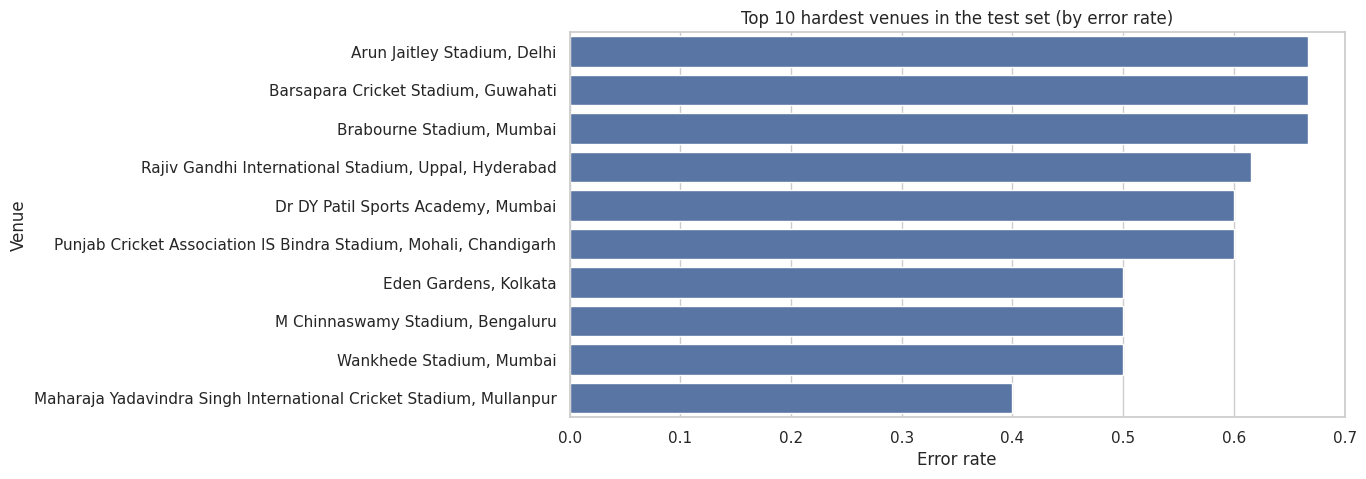

In [32]:
# Error rate by venue (only venues with at least 3 test matches)
venue_error = (
    analysis_df.groupby("venue")
    .agg(test_matches=("correct", "size"), accuracy=("correct", "mean"))
    .assign(error_rate=lambda x: 1 - x["accuracy"])
    .query("test_matches >= 3")
    .sort_values("error_rate", ascending=False)
)

display(venue_error.head(10).round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=venue_error.head(10).reset_index(), x="error_rate", y="venue")
plt.title("Top 10 hardest venues in the test set (by error rate)")
plt.xlabel("Error rate")
plt.ylabel("Venue")
plt.show()

## 18. Explainability with SHAP

We use the **best test-set model** for explainability.

- **Global explanation:** SHAP summary plot
- **Local explanation:** SHAP waterfall plot for one individual match

Because this is a tabular neural network with one-hot encoded inputs, SHAP helps identify both:
- the most influential global predictors
- the feature pushes behind one specific prediction

In [33]:
# Choose the final Keras model that actually won on the test set
model_object_lookup = {
    "Simple MLP baseline": baseline_final_model,
    "Best Random Search MLP": random_final_model,
    "Best Bayesian / Optuna MLP": optuna_final_model,
}

if best_model_name == "Dummy baseline":
    explain_model_name = "Best Bayesian / Optuna MLP"
else:
    explain_model_name = best_model_name

explain_model = model_object_lookup[explain_model_name]

# Keep SHAP manageable: small background and explanation samples
background_size = min(80, len(X_trainval))
explain_size = min(60, len(X_test))

background_idx = np.random.RandomState(SEED).choice(len(X_trainval), size=background_size, replace=False)
explain_idx = np.random.RandomState(SEED + 1).choice(len(X_test), size=explain_size, replace=False)

background_data = X_trainval[background_idx]
X_explain = X_test[explain_idx]

def predict_fn(x):
    x = np.array(x, dtype=np.float32)
    return explain_model.predict(x, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_fn, background_data)
shap_values = explainer.shap_values(X_explain, nsamples=100)

# KernelExplainer can return a list or array depending on version/setup
if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("SHAP values shape:", np.array(shap_values).shape)
print("Explained model:", explain_model_name)

  0%|          | 0/60 [00:00<?, ?it/s]

SHAP values shape: (60, 128)
Explained model: Simple MLP baseline


/tmp/ipykernel_4041/299787310.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, feature_names=feature_names, max_display=15)


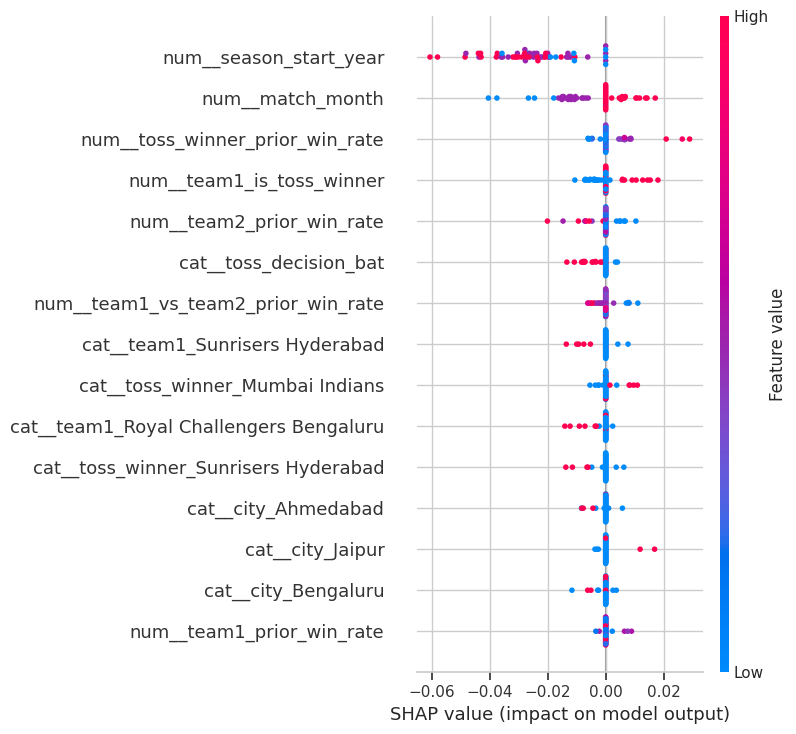

In [34]:
# Global explanation: summary plot
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, max_display=15)

,feature,mean_abs_shap
0,num__season_start_year,0.024804
1,num__match_month,0.009025
2,num__toss_winner_prior_win_rate,0.003096
3,num__team1_is_toss_winner,0.002963
4,num__team2_prior_win_rate,0.001895
5,cat__toss_decision_bat,0.001614
6,num__team1_vs_team2_prior_win_rate,0.001276
7,cat__team1_Sunrisers Hyderabad,0.000961
8,cat__toss_winner_Mumbai Indians,0.000952
9,cat__team1_Royal Challengers Bengaluru,0.000910


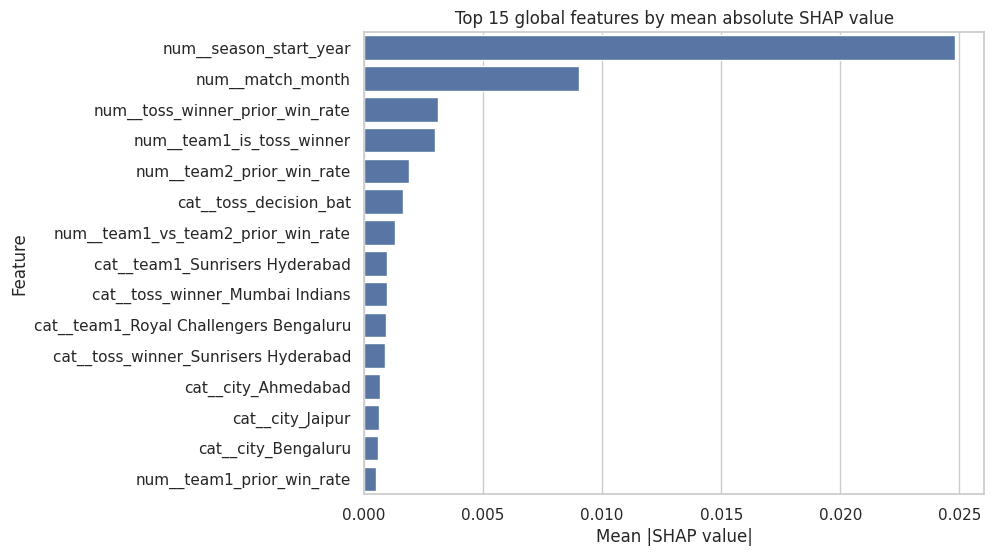

In [35]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
global_importance_df = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(global_importance_df.head(15).round(6))

plt.figure(figsize=(8, 6))
sns.barplot(data=global_importance_df.head(15), x="mean_abs_shap", y="feature")
plt.title("Top 15 global features by mean absolute SHAP value")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.show()

In [36]:
def plot_local_shap_waterfall(expected_value, shap_vector, data_vector, feature_names, max_display=15):
    # SHAP expected value can be scalar, list, or 1-element array depending on version/setup
    if isinstance(expected_value, (list, np.ndarray)):
        if np.ndim(expected_value) > 0:
            expected_value = float(np.array(expected_value).reshape(-1)[0])
        else:
            expected_value = float(expected_value)

    try:
        explanation = shap.Explanation(
            values=np.array(shap_vector),
            base_values=expected_value,
            data=np.array(data_vector),
            feature_names=np.array(feature_names),
        )
        shap.plots.waterfall(explanation, max_display=max_display)
    except Exception:
        shap.plots._waterfall.waterfall_legacy(
            expected_value,
            np.array(shap_vector),
            feature_names=feature_names,
            max_display=max_display,
        )

Predicted probability that Team1 wins: 0.5036


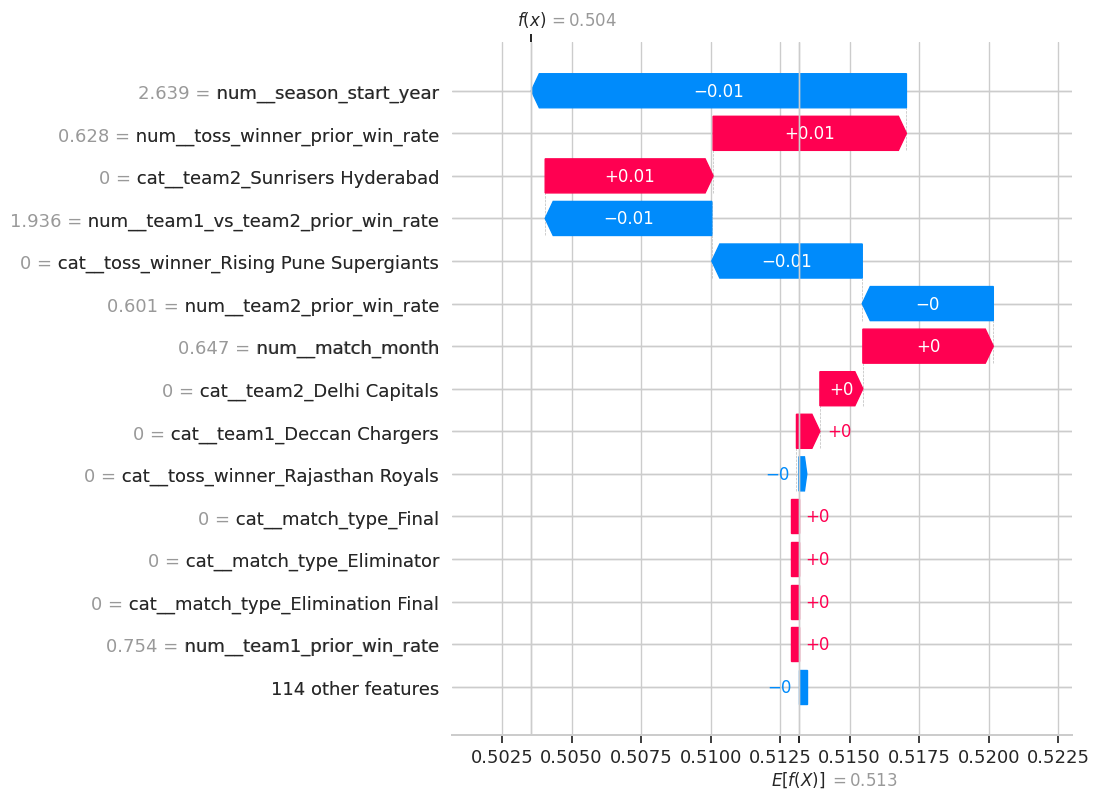

In [37]:
# Local explanation for one specific test sample
local_position = 0
local_sample = X_explain[local_position]
local_shap_values = shap_values[local_position]
local_prediction = predict_fn(local_sample.reshape(1, -1))[0]

print("Predicted probability that Team1 wins:", round(float(local_prediction), 4))
plot_local_shap_waterfall(
    explainer.expected_value,
    local_shap_values,
    local_sample,
    feature_names,
    max_display=15,
)

  0%|          | 0/1 [00:00<?, ?it/s]

Misclassified example:


,date,team1,team2,predicted_winner,actual_winner,confidence
0,2022-05-08,Chennai Super Kings,Delhi Capitals,Delhi Capitals,Chennai Super Kings,0.519886


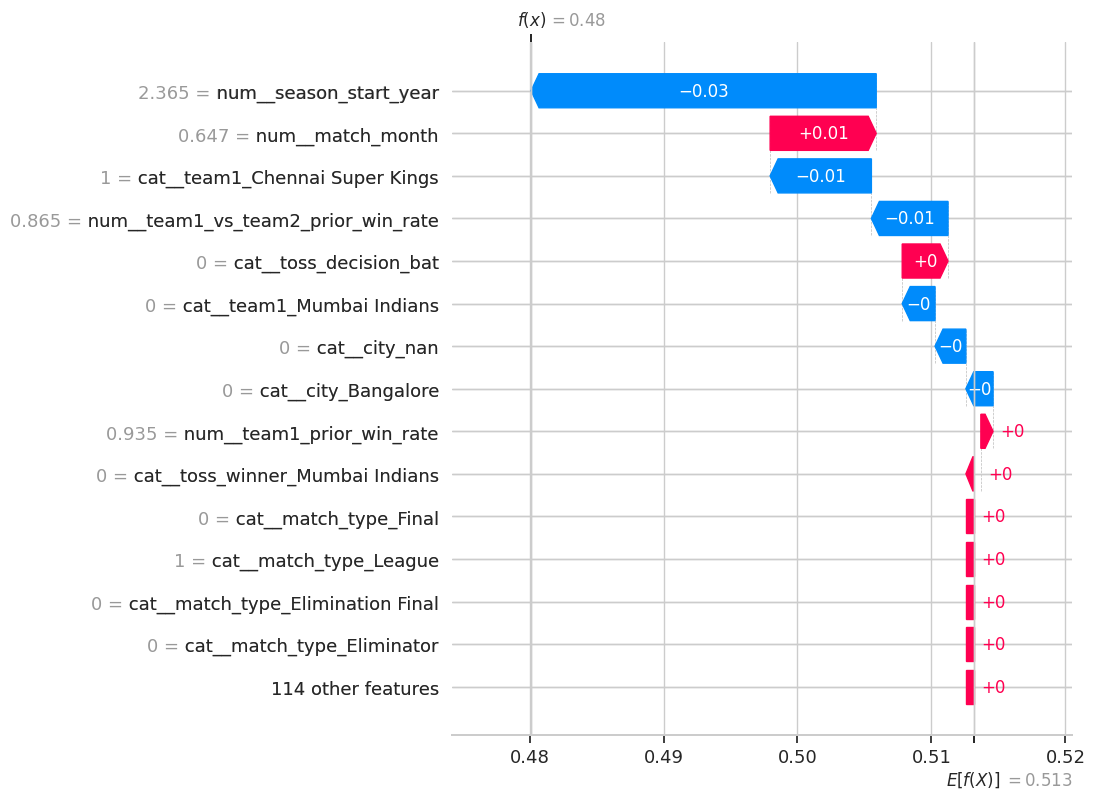

In [38]:
# Optional: inspect a misclassified test sample with SHAP if one exists
misclassified_positions = np.where(best_test_pred != y_test)[0]

if len(misclassified_positions) > 0:
    mis_idx = int(misclassified_positions[0])

    # Run SHAP on a single misclassified sample from the full test matrix
    mis_sample = X_test[mis_idx:mis_idx+1]
    mis_shap_values = explainer.shap_values(mis_sample, nsamples=100)
    if isinstance(mis_shap_values, list):
        mis_shap_values = mis_shap_values[0]

    print("Misclassified example:")
    display(analysis_df.loc[[mis_idx], ["date", "team1", "team2", "predicted_winner", "actual_winner", "confidence"]])

    plot_local_shap_waterfall(
        explainer.expected_value,
        mis_shap_values[0],
        mis_sample[0],
        feature_names,
        max_display=15,
    )
else:
    print("No misclassified samples found on the test set.")

## 19. Training challenges and adjustments made

1. **Small tabular sports dataset**
   - Only about 1K matches are available, so deep models can overfit quickly.

2. **Sparsity from categorical variables**
   - One-hot encoding of teams, venues, and cities increases dimensionality.

3. **Optimizer sensitivity**
   - SGD is usually more sensitive to learning rate than Adam on this dataset.

4. **Regularization needs**
   - Dropout and weight decay help control overfitting.
   - A learning-rate schedule can improve later-stage fine-tuning.

5. **Chronological uncertainty**
   - Team strength changes over seasons, so chronological splitting is stricter than random splitting.

In [39]:
# Compact training summary that is easy to reuse in the report
best_row = test_results.iloc[0].to_dict()

summary_points = [
    f"Best test-set model: {best_row['model']}",
    f"Best test accuracy: {best_row['accuracy']:.4f}",
    f"Best test F1: {best_row['f1']:.4f}",
    f"Best test ROC-AUC: {best_row['roc_auc']:.4f}",
    f"Random Search trials/runtime: {RANDOM_SEARCH_TRIALS} trials / {random_search_time:.2f}s",
    f"Bayesian Optimization trials/runtime: {OPTUNA_TRIALS} trials / {optuna_time:.2f}s",
    f"Best Random Search params: {random_best_params}",
    f"Best Optuna params: {optuna_best_params}",
]

for point in summary_points:
    print("•", point)

• Best test-set model: Simple MLP baseline
• Best test accuracy: 0.5244
• Best test F1: 0.3607
• Best test ROC-AUC: 0.5663
• Random Search trials/runtime: 50 trials / 173.20s
• Bayesian Optimization trials/runtime: 50 trials / 188.05s
• Best Random Search params: {'learning_rate': 0.00045560883012629716, 'batch_size': 128, 'dropout_rate': 0.5, 'hidden_units': 64, 'optimizer': 'rmsprop'}
• Best Optuna params: {'learning_rate': 0.00019746733539895237, 'batch_size': 128, 'dropout_rate': 0.2, 'hidden_units': 256, 'optimizer': 'sgd'}


## 20. Final conclusion

Hyperparameter optimization delivered mixed gains on this dataset. Random Search improved test accuracy by ~1.8 percentage points over the simple MLP baseline (54.27% vs 52.44%), and Optuna improved F1 by 22 points (0.5775 vs 0.3607), but neither method lifted ROC-AUC above the untuned baseline (0.5663). The ceiling appears to be genuine signal noise rather than a tuning limitation: IPL match outcomes are difficult to predict from pre-match and toss-time information alone, and both optimized models remained close to chance on a held-out chronological test set.

**Search strategy:** Random Search found a slightly stronger configuration by accuracy while Optuna found one with better F1. With only 50 trials, Optuna's TPE sampler did not show a decisive convergence advantage over random sampling — a larger trial budget would be needed to see the expected gap.

**Optimizer:** Adam reached the highest validation accuracy (56.44%) and was most stable across trials. SGD with momentum showed higher recall but volatile convergence at this learning-rate range. RMSProp settled in between.

**Regularization:** Dropout-only gave the best accuracy/F1 balance in ablation. Adding weight decay and a LR schedule pushed recall up but hurt precision. The full regularization stack did not help on a dataset this small.

**SHAP findings:** Prior win rates (, ) were the most globally influential features, followed by venue and toss information. Head-to-head history had a smaller but consistent effect. Toss outcome alone contributed very little, consistent with the low predictive power seen overall.

**Main limitations:** ~1 000 matches is a small sample for a neural network; gradient boosting would likely outperform here with less tuning. Pre-match features do not capture injury news, pitch conditions, or team form on the day — factors that domain experts weight heavily.

### Possible future work
- Add ball-by-ball derived features created **strictly from past matches only**
- Include player-level or venue-condition information if available
- Compare MLP with gradient boosting or tabular transformers
- Use nested time-based validation for even stricter evaluation

/tmp/ipykernel_4041/353644195.py:192: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, feature_names=feature_names, max_display=15, show=False)


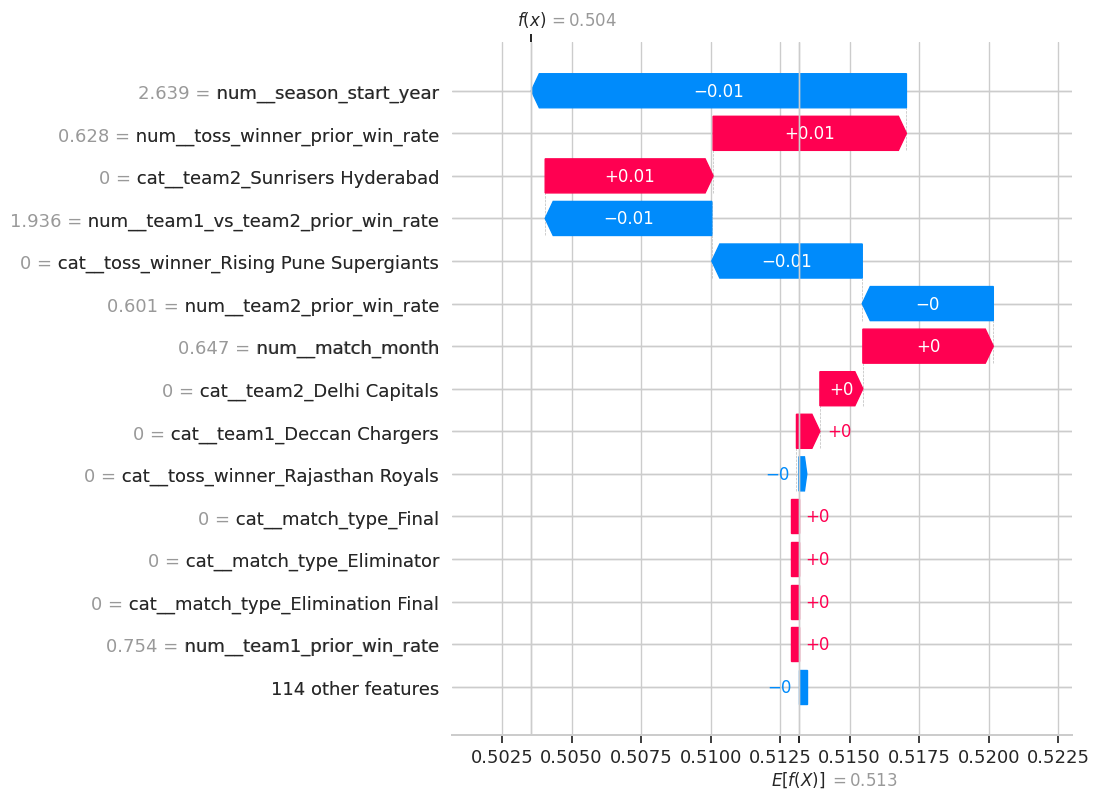

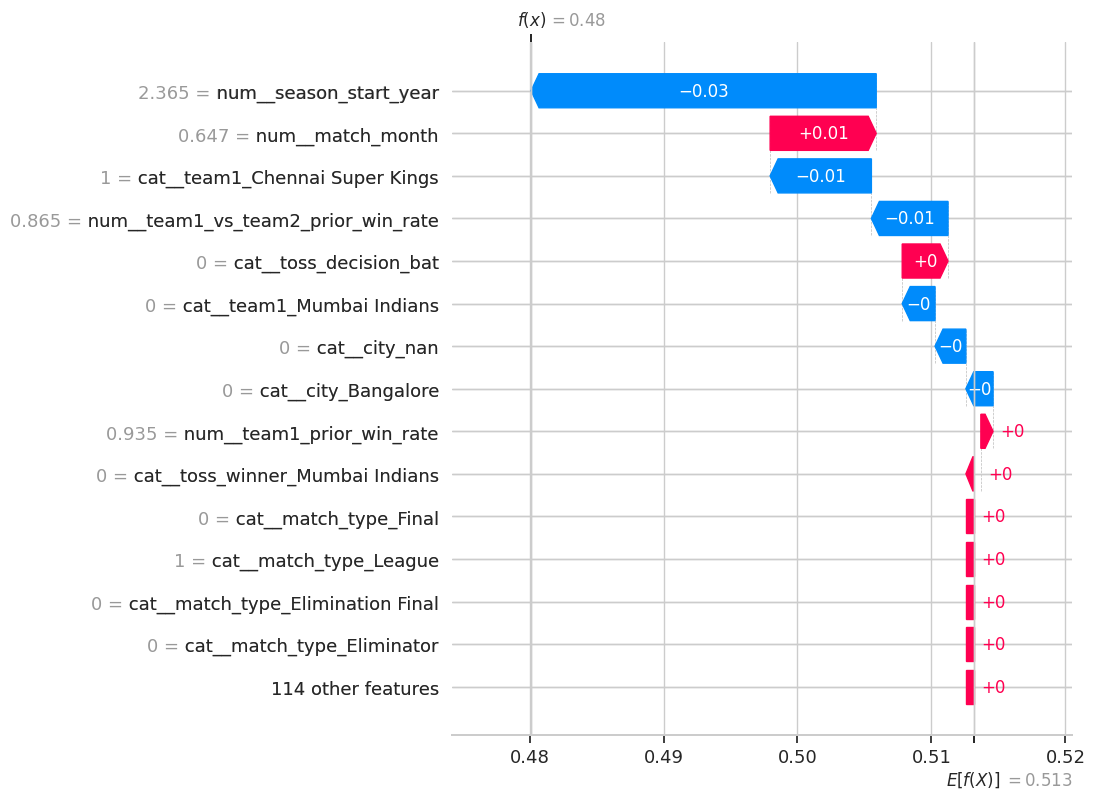

Exported assets folder: /content/ipl_project_outputs
Exported zip bundle:   /content/ipl_project_outputs.zip
Use the folder or the zip directly for your report/PPT.


In [41]:
# Automatic export bundle for report / PPT reuse
from pathlib import Path
import json
import zipfile
import re

def sanitize_filename(name):
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9._-]+", "_", name)   # replace / \ : spaces etc.
    name = re.sub(r"_+", "_", name).strip("._")
    return name or "unnamed"

OUTPUT_DIR = Path("ipl_project_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _to_serializable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, (Path,)):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]
    return obj

def save_df(df, filename):
    filename = sanitize_filename(filename)
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return str(path)

def save_fig(filename, fig=None, dpi=300):
    filename = sanitize_filename(filename)
    path = OUTPUT_DIR / filename
    if fig is None:
        fig = plt.gcf()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return str(path)

export_manifest = {"tables": [], "figures": [], "files": []}

# 1) CSV tables
table_objects = {
    "test_results_comparison.csv": test_results,
    "search_method_comparison.csv": comparison_search_df,
    "random_search_trials.csv": random_df,
    "optuna_trials.csv": optuna_trials_df,
    "global_shap_importance.csv": global_importance_df,
    "optimizer_ablation.csv": optimizer_ablation_df,
    "regularization_ablation.csv": regularization_df,
    "venue_error_analysis.csv": venue_error.reset_index(),
    "analysis_predictions.csv": analysis_df,
}
for filename, df_ in table_objects.items():
    export_manifest["tables"].append(save_df(df_, filename))

# 2) JSON summaries
summary_payload = {
    "seed": SEED,
    "random_search_trials": RANDOM_SEARCH_TRIALS,
    "optuna_trials": OPTUNA_TRIALS,
    "random_search_runtime_seconds": random_search_time,
    "optuna_runtime_seconds": optuna_time,
    "random_best_params": random_best_params,
    "optuna_best_params": optuna_best_params,
    "best_model_on_test": best_model_name,
    "test_results": _to_serializable(test_results.to_dict(orient="records")),
}
summary_json_path = OUTPUT_DIR / "project_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(_to_serializable(summary_payload), f, indent=2)
export_manifest["files"].append(str(summary_json_path))

summary_txt_path = OUTPUT_DIR / "project_summary.txt"
with open(summary_txt_path, "w", encoding="utf-8") as f:
    for point in summary_points:
        f.write(f"- {point}\n")
export_manifest["files"].append(str(summary_txt_path))

# 3) Re-create and save figures cleanly

# Baseline loss curve
fig = plt.figure(figsize=(8, 4))
plt.plot(baseline_history.history["loss"], label="Train loss")
plt.plot(baseline_history.history["val_loss"], label="Validation loss")
plt.title("Simple MLP baseline loss curve")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
export_manifest["figures"].append(save_fig("baseline_loss_curve.png", fig))

# Random Search convergence
fig = plt.figure(figsize=(8, 4))
plt.plot(random_df_plot["trial"], random_df_plot["roc_auc"], marker="o", label="Validation ROC-AUC per trial")
plt.plot(random_df_plot["trial"], random_df_plot["best_so_far_auc"], marker="s", label="Best-so-far ROC-AUC")
plt.title("Random Search convergence")
plt.xlabel("Trial")
plt.ylabel("Validation ROC-AUC")
plt.legend()
export_manifest["figures"].append(save_fig("random_search_convergence.png", fig))

# Optuna convergence
fig = plt.figure(figsize=(8, 4))
plt.plot(optuna_plot_df["number"] + 1, optuna_plot_df["roc_auc"], marker="o", label="Validation ROC-AUC per trial")
plt.plot(optuna_plot_df["number"] + 1, optuna_plot_df["best_so_far_auc"], marker="s", label="Best-so-far ROC-AUC")
plt.title("Bayesian Optimization (Optuna) convergence")
plt.xlabel("Trial")
plt.ylabel("Validation ROC-AUC")
plt.legend()
export_manifest["figures"].append(save_fig("optuna_convergence.png", fig))

# Best Optuna loss curve
fig = plt.figure(figsize=(8, 4))
plt.plot(optuna_best_history.history["loss"], label="Train loss")
plt.plot(optuna_best_history.history["val_loss"], label="Validation loss")
plt.title("Best Bayesian-optimized model loss curve")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
export_manifest["figures"].append(save_fig("optuna_best_loss_curve.png", fig))

# Search method comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=comparison_search_df, x="method", y="best_val_roc_auc", ax=axes[0])
axes[0].set_title("Best validation ROC-AUC by search method")
axes[0].tick_params(axis="x", rotation=15)
sns.barplot(data=comparison_search_df, x="method", y="runtime_seconds", ax=axes[1])
axes[1].set_title("Runtime by search method")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
export_manifest["figures"].append(save_fig("search_method_comparison.png", fig))

# Optimizer + regularization ablation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=optimizer_ablation_df, x="optimizer", y="roc_auc", ax=axes[0])
axes[0].set_title("Optimizer comparison (validation ROC-AUC)")
sns.barplot(data=regularization_df, x="setting", y="roc_auc", ax=axes[1])
axes[1].set_title("Regularization / LR schedule comparison")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
export_manifest["figures"].append(save_fig("ablation_comparison.png", fig))

# Test metrics comparison
fig = plt.figure(figsize=(10, 5))
sns.barplot(data=metric_plot_df, x="metric", y="score", hue="model")
plt.title("Test-set comparison across key metrics")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
export_manifest["figures"].append(save_fig("test_metric_comparison.png", fig))

# ROC curves
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, probs in prob_lookup.items():
    RocCurveDisplay.from_predictions(y_test, probs, name=model_name, ax=ax)
ax.set_title("ROC curves on the test set")
export_manifest["figures"].append(save_fig("roc_curves_test.png", fig))

# PR curves
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, probs in prob_lookup.items():
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=model_name, ax=ax)
ax.set_title("Precision-Recall curves on the test set")
export_manifest["figures"].append(save_fig("precision_recall_curves_test.png", fig))

# Hardest venues
fig = plt.figure(figsize=(10, 5))
sns.barplot(data=venue_error.head(10).reset_index(), x="error_rate", y="venue")
plt.title("Top 10 hardest venues in the test set (by error rate)")
plt.xlabel("Error rate")
plt.ylabel("Venue")
export_manifest["figures"].append(save_fig("hardest_venues_error_rate.png", fig))

# Confusion matrices for all models
for model_name, probs in prob_lookup.items():
    preds = (np.asarray(probs) >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Team2 wins", "Team1 wins"]).plot(ax=ax, values_format="d")
    ax.set_title(f"Confusion Matrix - {model_name}")
    safe_name = sanitize_filename(model_name)
    export_manifest["figures"].append(save_fig(f"confusion_matrix_{safe_name}.png", fig))

# SHAP global summary
try:
    shap.summary_plot(shap_values, X_explain, feature_names=feature_names, max_display=15, show=False)
    fig = plt.gcf()
    export_manifest["figures"].append(save_fig("shap_global_summary.png", fig))
except Exception as e:
    print("Could not save SHAP global summary:", e)

# SHAP local explanation (same sample used in notebook)
try:
    plot_local_shap_waterfall(
        explainer.expected_value,
        local_shap_values,
        local_sample,
        feature_names,
        max_display=15,
    )
    fig = plt.gcf()
    export_manifest["figures"].append(save_fig("shap_local_waterfall_sample0.png", fig))
except Exception as e:
    print("Could not save SHAP local waterfall for sample 0:", e)

# SHAP local explanation for one misclassified sample if available
try:
    if len(misclassified_positions) > 0:
        plot_local_shap_waterfall(
            explainer.expected_value,
            mis_shap_values[0],
            mis_sample[0],
            feature_names,
            max_display=15,
        )
        fig = plt.gcf()
        export_manifest["figures"].append(save_fig("shap_local_waterfall_misclassified.png", fig))
except Exception as e:
    print("Could not save SHAP misclassified-sample waterfall:", e)

# 4) Save manifest before zipping
manifest_path = OUTPUT_DIR / "export_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(_to_serializable(export_manifest), f, indent=2)
export_manifest["files"].append(str(manifest_path))

# 5) Zip everything into one downloadable bundle
zip_path = Path("ipl_project_outputs.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path_str in export_manifest["tables"] + export_manifest["figures"] + export_manifest["files"]:
        path_obj = Path(path_str)
        if path_obj.exists():
            zf.write(path_obj, arcname=path_obj.relative_to(OUTPUT_DIR))

print(f"Exported assets folder: {OUTPUT_DIR.resolve()}")
print(f"Exported zip bundle:   {zip_path.resolve()}")
print("Use the folder or the zip directly for your report/PPT.")